# GujEstateAI — Phase 4: Module 1 — Project Duration Prediction
**Input  :** `data/processed/features.csv` + `models/encoders.pkl`  
**Output :** `models/duration_model.pkl`  
**Goal   :** Predict how many months a project will take to complete  
**Target :** `duration_months`  
**Type   :** Regression  

Run cells one by one, top to bottom.
---

## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.linear_model     import Ridge
from sklearn.ensemble         import RandomForestRegressor
from sklearn.metrics          import mean_absolute_error, r2_score
from sklearn.preprocessing    import LabelEncoder
from xgboost                  import XGBRegressor
from lightgbm                 import LGBMRegressor

# Fix: block torch before importing shap
import sys
sys.modules["torch"] = None

import shap

print("All libraries imported successfully")

All libraries imported successfully


## Cell 2 — Load Features Data

In [2]:
df = pd.read_csv("../data/processed/features.csv")

print(f"Data loaded")
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print()
print("Target column — duration_months:")
print(f"  Min    : {df['duration_months'].min():.0f} months")
print(f"  Median : {df['duration_months'].median():.0f} months  ({df['duration_months'].median()/12:.1f} years)")
print(f"  Mean   : {df['duration_months'].mean():.1f} months  ({df['duration_months'].mean()/12:.1f} years)")
print(f"  Max    : {df['duration_months'].max():.0f} months")

Data loaded
  Rows    : 13,425
  Columns : 50

Target column — duration_months:
  Min    : 3 months
  Median : 51 months  (4.2 years)
  Mean   : 53.4 months  (4.4 years)
  Max    : 213 months


## Cell 3 — Extra Feature Engineering
We create more powerful features on top of Phase 3 features.  
The key idea: **district-level, project-type-level, and year-level averages**  
give the model historical context — e.g. 'Ahmedabad projects usually take 48 months'.

In [3]:
# ── Log transforms of more cost columns ─────────────────────
df["log_land_cost"]     = np.log1p(df["totalLandCost"])
df["log_develop_cost"]  = np.log1p(df["totalDevelopCost"])
df["log_selling"]       = np.log1p(df["totalSellingAmount"])
df["log_carpet"]        = np.log1p(df["totalCarpetArea_form3A"])
df["log_buildup"]       = np.log1p(df["totalBuiltupArea_form3A"])
df["log_sqft_build"]    = np.log1p(df["totalSquareFootBuild"])
df["log_cost_per_unit"] = np.log1p(df["cost_per_unit"])

# ── Start month (more granular than quarter) ──────────────────
df["start_month"] = df["startProjectMonth"].astype(int)

# ── Sell to develop ratio ─────────────────────────────────────
df["sell_dev_ratio"] = df["totalSellingAmount"] / df["totalDevelopCost"]
df["sell_dev_ratio"] = df["sell_dev_ratio"].replace([np.inf, -np.inf], np.nan)
df["sell_dev_ratio"] = df["sell_dev_ratio"].fillna(df["sell_dev_ratio"].median())
df["sell_dev_ratio"] = df["sell_dev_ratio"].clip(0, df["sell_dev_ratio"].quantile(0.99))

# ── District-level historical averages ───────────────────────
# "What is the typical duration for projects in this district?"
dist_agg = df.groupby("distName").agg(
    dist_avg_duration    = ("duration_months", "mean"),
    dist_median_duration = ("duration_months", "median"),
    dist_project_count   = ("duration_months", "count"),
    dist_avg_cost        = ("totalEstimatedCost", "mean"),
).reset_index()
df = df.merge(dist_agg, on="distName", how="left")

# ── Project type-level historical averages ───────────────────
# "What is the typical duration for this project type?"
type_agg = df.groupby("projectType").agg(
    type_avg_duration    = ("duration_months", "mean"),
    type_median_duration = ("duration_months", "median"),
).reset_index()
df = df.merge(type_agg, on="projectType", how="left")

# ── Year-level averages ───────────────────────────────────────
# "Were projects that started in this year generally faster/slower?"
year_agg = df.groupby("startProjectYear").agg(
    year_avg_duration  = ("duration_months", "mean"),
    year_project_count = ("duration_months", "count"),
).reset_index()
df = df.merge(year_agg, on="startProjectYear", how="left")

print("Extra features created!")
new_feat_count = 13
print(f"  Added {new_feat_count} new features")
print(f"  Total columns now: {df.shape[1]}")

Extra features created!
  Added 13 new features
  Total columns now: 66


## Cell 4 — Define Features and Target
We now use **33 features** instead of 11.  
More relevant features = better model.

In [4]:
FEATURES = [
    # ── Categorical (encoded) ──────────────────────────────
    "projectType_enc",            # type of project
    "distName_enc",               # district
    "promoter_type_simple_enc",   # who is building

    # ── Units and size ──────────────────────────────────────
    "totalUnits",
    "log_units",
    "noOfInventory",
    "totalProjects",

    # ── Cost features ───────────────────────────────────────
    "log_cost",
    "log_land_cost",
    "log_develop_cost",
    "log_selling",
    "log_carpet",
    "log_buildup",
    "log_sqft_build",
    "log_cost_per_unit",
    "cost_per_unit",
    "avgCostPerSqFt",
    "avgCostPerUnit",

    # ── Ratio features ──────────────────────────────────────
    "land_cost_ratio",
    "sell_dev_ratio",
    "booking_rate",

    # ── Time features ───────────────────────────────────────
    "is_redevelop",
    "startProjectYear",
    "start_month",
    "start_quarter",

    # ── District-level historical context ───────────────────
    "dist_avg_duration",
    "dist_median_duration",
    "dist_project_count",
    "dist_avg_cost",

    # ── Project type historical context ─────────────────────
    "type_avg_duration",
    "type_median_duration",

    # ── Year-level historical context ───────────────────────
    "year_avg_duration",
    "year_project_count",
]

TARGET = "duration_months"

print(f"Total features : {len(FEATURES)}")
print(f"Target         : {TARGET}")

Total features : 33
Target         : duration_months


## Cell 5 — Prepare X and y

In [5]:
# Drop rows where any feature or target is null
df_model = df.dropna(subset=FEATURES + [TARGET]).copy()

X = df_model[FEATURES]
y = df_model[TARGET]

print(f"X shape : {X.shape}  (rows, features)")
print(f"y shape : {y.shape}  (rows,)")
print(f"Nulls in X : {X.isnull().sum().sum()}")
print(f"Nulls in y : {y.isnull().sum()}")

X shape : (13425, 33)  (rows, features)
y shape : (13425,)  (rows,)
Nulls in X : 0
Nulls in y : 0


## Cell 6 — Split into Train and Test Sets
We keep 20% of data aside for testing.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42
)

print(f"Training set : {X_train.shape[0]:,} rows  (80%)")
print(f"Test set     : {X_test.shape[0]:,} rows  (20%)")

Training set : 10,740 rows  (80%)
Test set     : 2,685 rows  (20%)


## Cell 7 — Model 1: Ridge Regression (Baseline)
Simple linear model. Used as baseline to compare against.

In [7]:
ridge = Ridge()
ridge.fit(X_train, y_train)

preds_ridge = ridge.predict(X_test)
mae_ridge   = mean_absolute_error(y_test, preds_ridge)
r2_ridge    = r2_score(y_test, preds_ridge)

print("RIDGE REGRESSION RESULTS:")
print("-" * 38)
print(f"  MAE : {mae_ridge:.2f} months")
print(f"  R2  : {r2_ridge:.4f}")

RIDGE REGRESSION RESULTS:
--------------------------------------
  MAE : 12.25 months
  R2  : 0.4192


## Cell 8 — Model 2: Random Forest
Builds many decision trees and averages their predictions.

In [8]:
rf = RandomForestRegressor(
    n_estimators = 200,
    random_state = 42,
    n_jobs       = -1
)
rf.fit(X_train, y_train)

preds_rf = rf.predict(X_test)
mae_rf   = mean_absolute_error(y_test, preds_rf)
r2_rf    = r2_score(y_test, preds_rf)

print("RANDOM FOREST RESULTS:")
print("-" * 38)
print(f"  MAE : {mae_rf:.2f} months")
print(f"  R2  : {r2_rf:.4f}")

RANDOM FOREST RESULTS:
--------------------------------------
  MAE : 12.03 months
  R2  : 0.4342


## Cell 9 — Model 3: XGBoost
Gradient boosting — builds trees one by one, each correcting previous mistakes.

In [9]:
xgb = XGBRegressor(
    n_estimators    = 600,
    learning_rate   = 0.02,
    max_depth       = 6,
    min_child_weight= 3,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    random_state    = 42,
    verbosity       = 0
)
xgb.fit(X_train, y_train)

preds_xgb = xgb.predict(X_test)
mae_xgb   = mean_absolute_error(y_test, preds_xgb)
r2_xgb    = r2_score(y_test, preds_xgb)

print("XGBOOST RESULTS:")
print("-" * 38)
print(f"  MAE : {mae_xgb:.2f} months")
print(f"  R2  : {r2_xgb:.4f}")

XGBOOST RESULTS:
--------------------------------------
  MAE : 11.77 months
  R2  : 0.4542


## Cell 10 — Model 4: LightGBM
Similar to XGBoost but faster. Often gets similar or better results.

In [10]:
lgbm = LGBMRegressor(
    n_estimators  = 600,
    learning_rate = 0.02,
    max_depth     = 6,
    random_state  = 42,
    verbose       = -1
)
lgbm.fit(X_train, y_train)

preds_lgbm = lgbm.predict(X_test)
mae_lgbm   = mean_absolute_error(y_test, preds_lgbm)
r2_lgbm    = r2_score(y_test, preds_lgbm)

print("LIGHTGBM RESULTS:")
print("-" * 38)
print(f"  MAE : {mae_lgbm:.2f} months")
print(f"  R2  : {r2_lgbm:.4f}")

  File "c:\Users\VASU MONPARA\OneDrive\Desktop\GujEstateAI Gujarat Real Estate Prediction System\gpu_env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 251, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\VASU MONPARA\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\VASU MONPARA\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\VASU MONPARA\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


LIGHTGBM RESULTS:
--------------------------------------
  MAE : 11.85 months
  R2  : 0.4496


## Cell 11 — Compare All 4 Models

  MODEL COMPARISON
        Model  MAE (months)  R2 Score
        Ridge         12.25    0.4192
Random Forest         12.03    0.4342
      XGBoost         11.77    0.4542
     LightGBM         11.85    0.4496

  Best model : XGBoost
  Best R2    : 0.4542
  Best MAE   : 11.77 months

  Using XGBoost for charts and SHAP below.


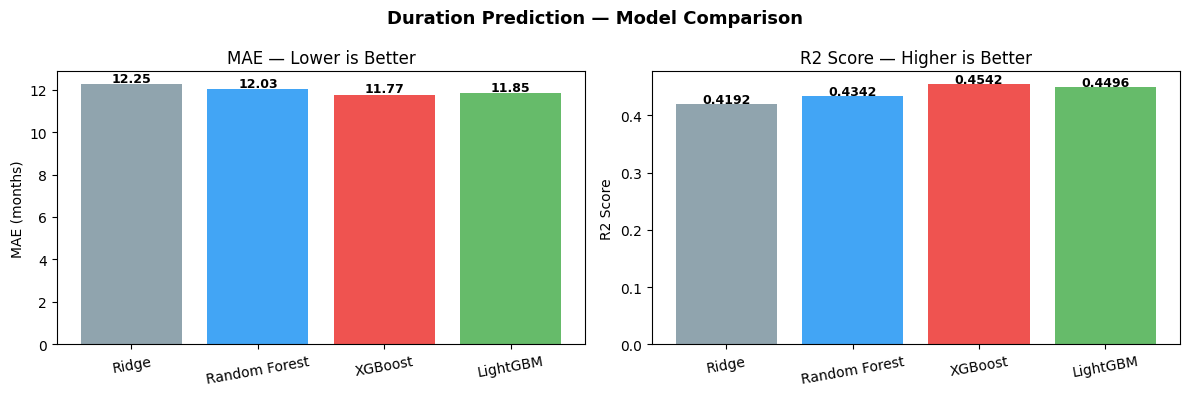

In [11]:
results = pd.DataFrame({
    "Model"       : ["Ridge", "Random Forest", "XGBoost", "LightGBM"],
    "MAE (months)": [round(mae_ridge,2), round(mae_rf,2), round(mae_xgb,2), round(mae_lgbm,2)],
    "R2 Score"    : [round(r2_ridge,4),  round(r2_rf,4),  round(r2_xgb,4),  round(r2_lgbm,4)],
})

print("=" * 50)
print("  MODEL COMPARISON")
print("=" * 50)
print(results.to_string(index=False))
best_idx = results["R2 Score"].idxmax()
print(f"\n  Best model : {results.loc[best_idx, 'Model']}")
print(f"  Best R2    : {results.loc[best_idx, 'R2 Score']}")
print(f"  Best MAE   : {results.loc[best_idx, 'MAE (months)']} months")

# pick best model for rest of notebook
best_model  = xgb if r2_xgb >= r2_lgbm else lgbm
best_preds  = preds_xgb if r2_xgb >= r2_lgbm else preds_lgbm
best_name   = "XGBoost" if r2_xgb >= r2_lgbm else "LightGBM"
best_mae    = mae_xgb if r2_xgb >= r2_lgbm else mae_lgbm
best_r2     = r2_xgb if r2_xgb >= r2_lgbm else r2_lgbm
print(f"\n  Using {best_name} for charts and SHAP below.")

# Bar charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#90A4AE","#42A5F5","#EF5350","#66BB6A"]

axes[0].bar(results["Model"], results["MAE (months)"], color=colors)
for i, v in enumerate(results["MAE (months)"]):
    axes[0].text(i, v+0.1, str(v), ha="center", fontweight="bold", fontsize=9)
axes[0].set_title("MAE — Lower is Better")
axes[0].set_ylabel("MAE (months)")
axes[0].tick_params(axis="x", rotation=10)

axes[1].bar(results["Model"], results["R2 Score"], color=colors)
for i, v in enumerate(results["R2 Score"]):
    axes[1].text(i, v+0.002, str(v), ha="center", fontweight="bold", fontsize=9)
axes[1].set_title("R2 Score — Higher is Better")
axes[1].set_ylabel("R2 Score")
axes[1].tick_params(axis="x", rotation=10)

plt.suptitle("Duration Prediction — Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/14_model_comparison_duration.png", dpi=150)
plt.show()

## Cell 12 — Cross Validation
Tests the model on 5 different splits for a reliable score.

In [12]:
cv_scores = cross_val_score(
    XGBRegressor(n_estimators=600, learning_rate=0.02, max_depth=6,
                 min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
                 random_state=42, verbosity=0),
    X, y, cv=5, scoring="neg_mean_absolute_error"
)
cv_mae = -cv_scores

print("XGBOOST — 5-FOLD CROSS VALIDATION:")
print("-" * 40)
for i, score in enumerate(cv_mae, 1):
    print(f"  Fold {i} : MAE = {score:.2f} months")
print(f"\n  Average MAE : {cv_mae.mean():.2f} months")
print(f"  Std Dev     : {cv_mae.std():.2f} months")

XGBOOST — 5-FOLD CROSS VALIDATION:
----------------------------------------
  Fold 1 : MAE = 13.44 months
  Fold 2 : MAE = 11.43 months
  Fold 3 : MAE = 11.89 months
  Fold 4 : MAE = 11.69 months
  Fold 5 : MAE = 11.79 months

  Average MAE : 12.05 months
  Std Dev     : 0.71 months


## Cell 13 — Feature Importance
Which features matter most? Shows what the model actually learned.

TOP 15 FEATURE IMPORTANCES (XGBoost):
---------------------------------------------
  startProjectYear                0.1501  ██████████████████████████████
  dist_median_duration            0.1086  █████████████████████
  log_develop_cost                0.0640  ████████████
  year_avg_duration               0.0637  ████████████
  dist_avg_duration               0.0572  ███████████
  year_project_count              0.0542  ██████████
  log_buildup                     0.0337  ██████
  log_carpet                      0.0320  ██████
  type_median_duration            0.0309  ██████
  type_avg_duration               0.0306  ██████
  log_selling                     0.0295  █████
  log_sqft_build                  0.0245  ████
  dist_avg_cost                   0.0228  ████
  distName_enc                    0.0209  ████
  land_cost_ratio                 0.0187  ███


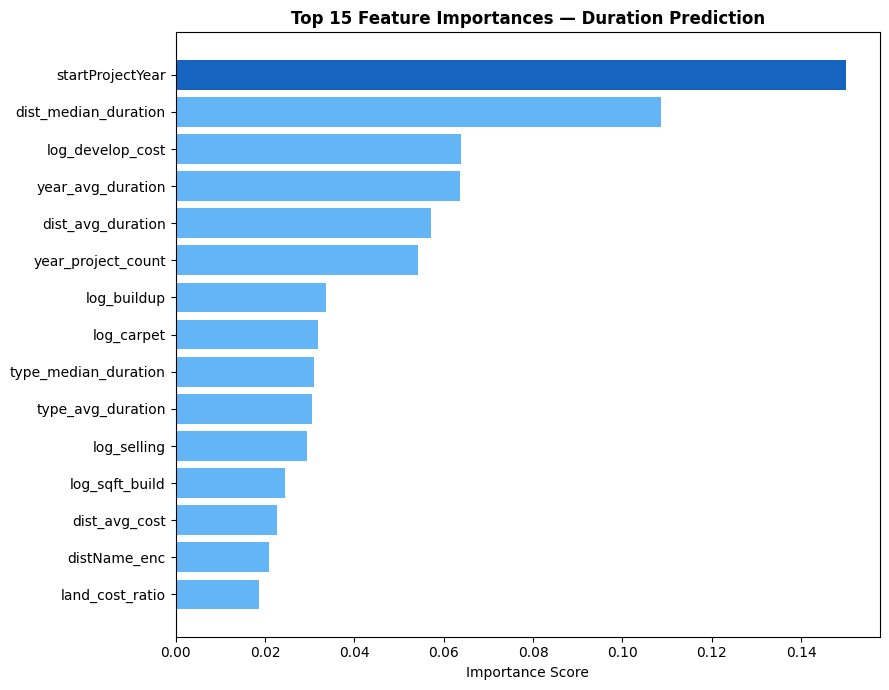

In [13]:
importances = pd.Series(
    xgb.feature_importances_,
    index = FEATURES
).sort_values(ascending=False)

print("TOP 15 FEATURE IMPORTANCES (XGBoost):")
print("-" * 45)
for feat, score in importances.head(15).items():
    bar = "█" * int(score * 200)
    print(f"  {feat:<30}  {score:.4f}  {bar}")

plt.figure(figsize=(9, 7))
top15 = importances.head(15)
colors_imp = ["#1565C0" if i == 0 else "#64B5F6" for i in range(len(top15))]
plt.barh(top15.index[::-1], top15.values[::-1], color=colors_imp[::-1])
plt.title("Top 15 Feature Importances — Duration Prediction",
          fontsize=12, fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("../reports/15_feature_importance_duration.png", dpi=150)
plt.show()

## Cell 14 — Actual vs Predicted Plot
Good model = dots close to the red diagonal line.

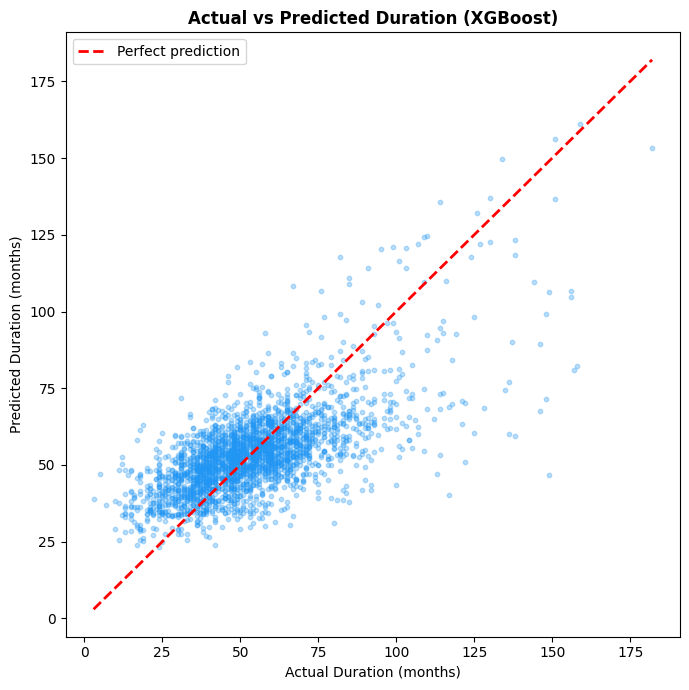

In [14]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_preds, alpha=0.3, color="#2196F3", s=10)
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, color="red", linewidth=2, linestyle="--", label="Perfect prediction")
plt.title(f"Actual vs Predicted Duration ({best_name})", fontsize=12, fontweight="bold")
plt.xlabel("Actual Duration (months)")
plt.ylabel("Predicted Duration (months)")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/16_actual_vs_predicted_duration.png", dpi=150)
plt.show()

## Cell 15 — Prediction Error Distribution
Good model has errors centered around 0.

PREDICTION ERROR ANALYSIS:
--------------------------------------
  Mean error         : 0.07 months
  Std of error       : 15.64 months
  Within +-6 months  : 33.3%
  Within +-12 months : 61.4%
  Within +-24 months : 90.2%


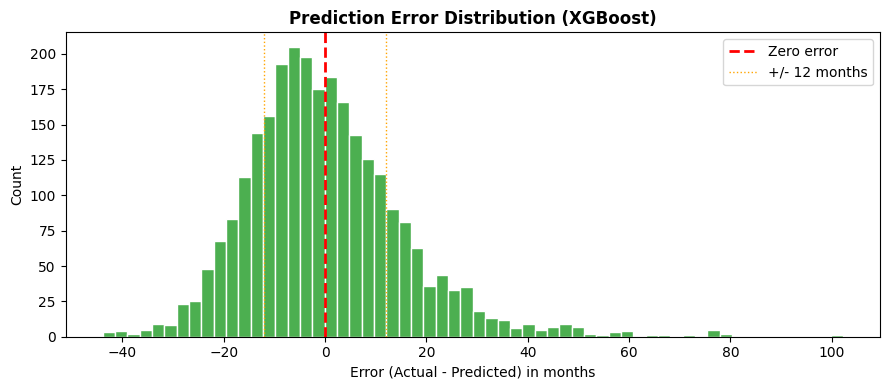

In [15]:
errors = y_test.values - best_preds

print("PREDICTION ERROR ANALYSIS:")
print("-" * 38)
print(f"  Mean error         : {errors.mean():.2f} months")
print(f"  Std of error       : {errors.std():.2f} months")
print(f"  Within +-6 months  : {(np.abs(errors)<=6).mean()*100:.1f}%")
print(f"  Within +-12 months : {(np.abs(errors)<=12).mean()*100:.1f}%")
print(f"  Within +-24 months : {(np.abs(errors)<=24).mean()*100:.1f}%")

plt.figure(figsize=(9, 4))
plt.hist(errors, bins=60, color="#4CAF50", edgecolor="white")
plt.axvline(0,    color="red",    linewidth=2, linestyle="--", label="Zero error")
plt.axvline( 12,  color="orange", linewidth=1, linestyle=":",  label="+/- 12 months")
plt.axvline(-12,  color="orange", linewidth=1, linestyle=":")
plt.title(f"Prediction Error Distribution ({best_name})", fontsize=12, fontweight="bold")
plt.xlabel("Error (Actual - Predicted) in months")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/17_error_distribution_duration.png", dpi=150)
plt.show()

## Cell 16 — SHAP Values (Explainability)
SHAP explains **why** the model made each prediction.  
Uses `shap.Explainer` which works correctly with both XGBoost and LightGBM.

SHAP values computed successfully
  Shape: (2685, 33)


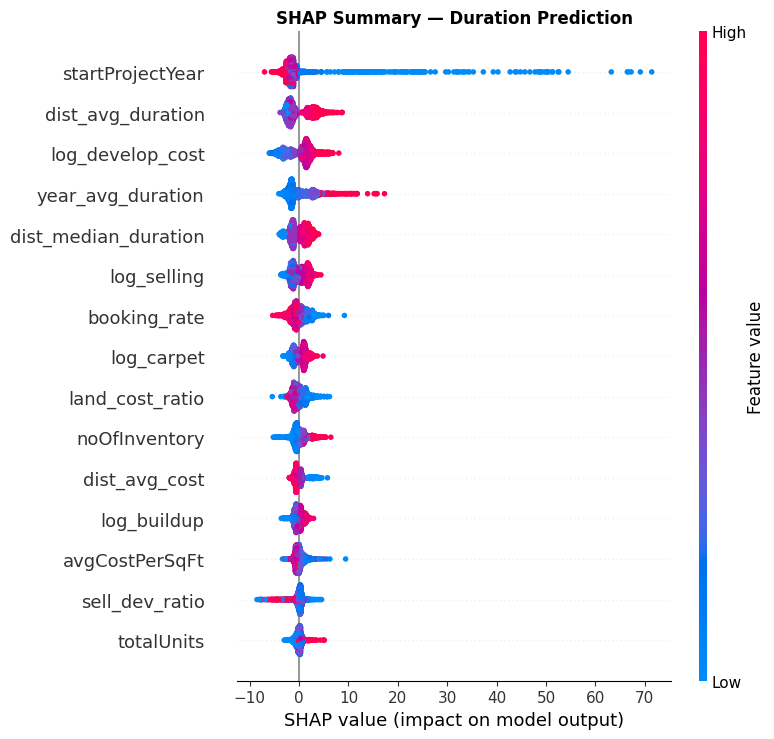

SHAP summary plot saved.


In [16]:
os.makedirs("../reports/shap_plots", exist_ok=True)

# Use TreeExplainer — fastest and most reliable for XGBoost/LightGBM
# Does NOT need torch at all
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print("SHAP values computed successfully")
print(f"  Shape: {shap_values.shape}")

# Summary plot
plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    feature_names = FEATURES,
    max_display   = 15,
    show          = False
)
plt.title("SHAP Summary — Duration Prediction", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/shap_plots/18_shap_duration.png", dpi=150, bbox_inches="tight")
plt.show()
print("SHAP summary plot saved.")

## Cell 17 — SHAP Waterfall Plot (One Prediction Explained)
Pick one project and explain exactly why the model predicted what it did.

Sample project:
  Actual duration    : 61 months  (5.1 years)
  Predicted duration : 58.6 months  (4.9 years)
  Error              : 2.4 months


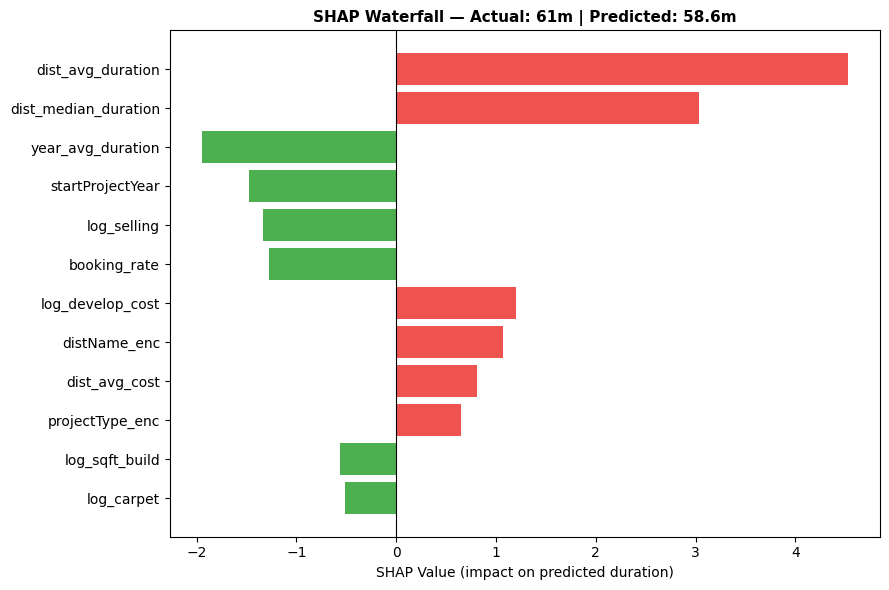

Waterfall plot saved.


In [17]:
sample_idx = 0
actual_dur = y_test.iloc[sample_idx]
pred_dur   = best_preds[sample_idx]

print(f"Sample project:")
print(f"  Actual duration    : {actual_dur:.0f} months  ({actual_dur/12:.1f} years)")
print(f"  Predicted duration : {pred_dur:.1f} months  ({pred_dur/12:.1f} years)")
print(f"  Error              : {abs(actual_dur - pred_dur):.1f} months")

# Manual waterfall — works without torch
shap_sample = shap_values[sample_idx]
sorted_idx  = np.argsort(np.abs(shap_sample))[::-1][:12]
feat_names  = [FEATURES[i] for i in sorted_idx]
feat_shap   = shap_sample[sorted_idx]
colors      = ["#EF5350" if v > 0 else "#4CAF50" for v in feat_shap]

plt.figure(figsize=(9, 6))
plt.barh(feat_names[::-1], feat_shap[::-1], color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.title(
    f"SHAP Waterfall — Actual: {actual_dur:.0f}m | Predicted: {pred_dur:.1f}m",
    fontsize=11, fontweight="bold"
)
plt.xlabel("SHAP Value (impact on predicted duration)")
plt.tight_layout()
plt.savefig("../reports/shap_plots/19_shap_waterfall_duration.png", dpi=150)
plt.show()
print("Waterfall plot saved.")

## Cell 18 — Save the Best Model
Save to disk for use in the unified pipeline and Streamlit dashboard.

In [18]:
os.makedirs("../models", exist_ok=True)

joblib.dump(xgb, "../models/duration_model.pkl")

print("Model saved: models/duration_model.pkl")

# Quick reload test
loaded = joblib.load("../models/duration_model.pkl")
test   = loaded.predict(X_test.iloc[:3])
print(f"Reload test predictions: {test.round(1)}")
print("Reload successful!")

Model saved: models/duration_model.pkl
Reload test predictions: [58.6 56.6 57.3]
Reload successful!


## Cell 19 — Manual Prediction Test
Test the model with a sample project you create manually.

In [19]:
encoders = joblib.load("../models/encoders.pkl")

# Build one sample row — Residential project in Ahmedabad, 120 units
sample = pd.DataFrame([{
    "projectType_enc"           : encoders["projectType"].transform(["Residential/Group Housing"])[0],
    "distName_enc"              : encoders["distName"].transform(["Ahmedabad"])[0],
    "promoter_type_simple_enc"  : encoders["promoter_type_simple"].transform(["Partnership"])[0],
    "totalUnits"                : 120,
    "log_units"                 : np.log1p(120),
    "noOfInventory"             : 120,
    "totalProjects"             : 1,
    "log_cost"                  : np.log1p(50_000_000),
    "log_land_cost"             : np.log1p(15_000_000),
    "log_develop_cost"          : np.log1p(35_000_000),
    "log_selling"               : np.log1p(60_000_000),
    "log_carpet"                : np.log1p(5000),
    "log_buildup"               : np.log1p(6000),
    "log_sqft_build"            : np.log1p(6500),
    "log_cost_per_unit"         : np.log1p(50_000_000 / 120),
    "cost_per_unit"             : 50_000_000 / 120,
    "avgCostPerSqFt"            : 8000,
    "avgCostPerUnit"            : 50_000_000 / 120,
    "land_cost_ratio"           : 15_000_000 / 50_000_000,
    "sell_dev_ratio"            : 60_000_000 / 35_000_000,
    "booking_rate"              : 0.5,
    "is_redevelop"              : 0,
    "startProjectYear"          : 2022,
    "start_month"               : 3,
    "start_quarter"             : 1,
    "dist_avg_duration"         : df[df["distName"]=="Ahmedabad"]["duration_months"].mean(),
    "dist_median_duration"      : df[df["distName"]=="Ahmedabad"]["duration_months"].median(),
    "dist_project_count"        : (df["distName"]=="Ahmedabad").sum(),
    "dist_avg_cost"             : df[df["distName"]=="Ahmedabad"]["totalEstimatedCost"].mean(),
    "type_avg_duration"         : df[df["projectType"]=="Residential/Group Housing"]["duration_months"].mean(),
    "type_median_duration"      : df[df["projectType"]=="Residential/Group Housing"]["duration_months"].median(),
    "year_avg_duration"         : df[df["startProjectYear"]==2022]["duration_months"].mean(),
    "year_project_count"        : (df["startProjectYear"]==2022).sum(),
}])

predicted = xgb.predict(sample)[0]

print("MANUAL PREDICTION TEST:")
print("-" * 38)
print(f"  Project   : Residential/Group Housing")
print(f"  District  : Ahmedabad")
print(f"  Units     : 120")
print(f"  Cost      : Rs 5 Crore")
print()
print(f"  Predicted Duration : {predicted:.1f} months  ({predicted/12:.1f} years)")

MANUAL PREDICTION TEST:
--------------------------------------
  Project   : Residential/Group Housing
  District  : Ahmedabad
  Units     : 120
  Cost      : Rs 5 Crore

  Predicted Duration : 42.9 months  (3.6 years)


## Cell 20 — Module 1 Final Summary

In [20]:
print()
print("=" * 55)
print("  MODULE 1 — DURATION PREDICTION — SUMMARY")
print("=" * 55)
print(f"  Features used  : {len(FEATURES)}  (upgraded from 11)")
print(f"  Training rows  : {X_train.shape[0]:,}")
print(f"  Test rows      : {X_test.shape[0]:,}")
print()
print("  RESULTS:")
print(f"    Ridge         — MAE: {mae_ridge:.2f} months   R2: {r2_ridge:.4f}")
print(f"    Random Forest — MAE: {mae_rf:.2f} months   R2: {r2_rf:.4f}")
print(f"    XGBoost       — MAE: {mae_xgb:.2f} months   R2: {r2_xgb:.4f}")
print(f"    LightGBM      — MAE: {mae_lgbm:.2f} months   R2: {r2_lgbm:.4f}")
print()
print("  SAVED FILES:")
print("    models/duration_model.pkl")
print("    reports/14_model_comparison_duration.png")
print("    reports/15_feature_importance_duration.png")
print("    reports/16_actual_vs_predicted_duration.png")
print("    reports/17_error_distribution_duration.png")
print("    reports/shap_plots/18_shap_duration.png")
print("    reports/shap_plots/19_shap_waterfall_duration.png")
print()
print("  Next: 05_module2_cost.ipynb")
print("=" * 55)


  MODULE 1 — DURATION PREDICTION — SUMMARY
  Features used  : 33  (upgraded from 11)
  Training rows  : 10,740
  Test rows      : 2,685

  RESULTS:
    Ridge         — MAE: 12.25 months   R2: 0.4192
    Random Forest — MAE: 12.03 months   R2: 0.4342
    XGBoost       — MAE: 11.77 months   R2: 0.4542
    LightGBM      — MAE: 11.85 months   R2: 0.4496

  SAVED FILES:
    models/duration_model.pkl
    reports/14_model_comparison_duration.png
    reports/15_feature_importance_duration.png
    reports/16_actual_vs_predicted_duration.png
    reports/17_error_distribution_duration.png
    reports/shap_plots/18_shap_duration.png
    reports/shap_plots/19_shap_waterfall_duration.png

  Next: 05_module2_cost.ipynb
